In [1]:
import pandas as pd
import torch
import matplotlib.pyplot as plt


In [2]:
df= pd.read_csv("06-study_hours_grades.csv")

In [3]:
df.head()

,study_hours,grade
0,3.745401,30.203939
1,9.507143,57.878452
2,7.319939,46.368401
3,5.986585,39.330717
4,1.560186,14.843888


In [4]:
X= torch.tensor(df["study_hours"].values, dtype= torch.float32).unsqueeze(1)
y= torch.tensor(df["grade"].values, dtype= torch.float32).unsqueeze(1)

In [5]:
X

tensor([[3.7454],
        [9.5071],
        [7.3199],
        [5.9866],
        [1.5602],
        [1.5599],
        [0.5808],
        [8.6618],
        [6.0111],
        [7.0807],
        [0.2058],
        [9.6991],
        [8.3244],
        [2.1234],
        [1.8182],
        [1.8340],
        [3.0424],
        [5.2476],
        [4.3195],
        [2.9123],
        [6.1185],
        [1.3949],
        [2.9214],
        [3.6636],
        [4.5607],
        [7.8518],
        [1.9967],
        [5.1423],
        [5.9241],
        [0.4645],
        [6.0754],
        [1.7052],
        [0.6505],
        [9.4889],
        [9.6563],
        [8.0840],
        [3.0461],
        [0.9767],
        [6.8423],
        [4.4015],
        [1.2204],
        [4.9518],
        [0.3439],
        [9.0932],
        [2.5878],
        [6.6252],
        [3.1171],
        [5.2007],
        [5.4671],
        [1.8485]])

In [6]:
y

tensor([[30.2039],
        [57.8785],
        [46.3684],
        [39.3307],
        [14.8439],
        [16.3600],
        [11.9829],
        [55.4230],
        [40.7430],
        [41.8775],
        [11.6774],
        [57.7253],
        [50.2683],
        [21.8403],
        [21.1532],
        [21.0328],
        [23.5337],
        [35.6194],
        [32.2598],
        [26.5125],
        [39.6343],
        [16.6034],
        [22.3946],
        [25.9257],
        [34.4286],
        [51.9713],
        [19.8397],
        [37.7188],
        [40.3440],
        [11.0323],
        [41.1000],
        [21.6023],
        [13.1809],
        [60.5736],
        [53.0421],
        [52.0637],
        [25.4048],
        [14.2856],
        [44.3952],
        [28.0325],
        [15.6626],
        [35.4731],
        [14.6752],
        [54.4295],
        [21.3220],
        [42.1226],
        [27.4164],
        [36.6609],
        [36.2760],
        [20.2693]])

In [7]:
X.shape

torch.Size([50, 1])

In [8]:
y.shape

torch.Size([50, 1])

In [9]:
X.ndim

2

In [10]:
train_split= int(0.8* len(X))
X_train, y_train= X[:train_split], y[:train_split]
X_test, y_test= X[train_split:], y[train_split:]

In [11]:
len(X_train), len(X_test)

(40, 10)

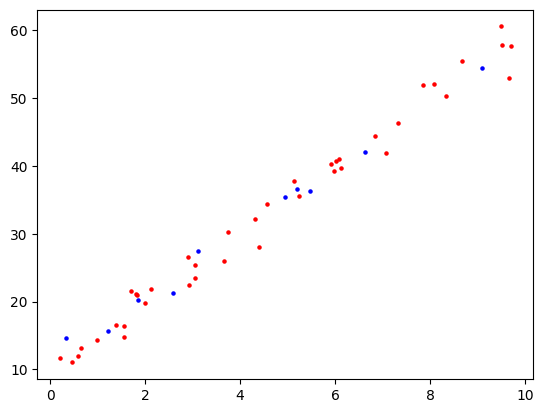

In [12]:
plt.scatter(X_train, y_train, s=5, c="r", label="Training Data")
plt.scatter(X_test, y_test, s=5, c="b", label="Training Data")
plt.show()

In [13]:
import torch.nn as nn

class LinearRegressionModel(nn.Module):
    def __init__(self):
        super().__init__()
        #weight and bias
        self.linear_layer= nn.Linear(in_features=1, out_features=1)

    #feed forward
    def forward(self,x: torch.Tensor)-> torch.Tensor:
        return self.linear_layer(x)
            
        

In [14]:
torch.manual_seed(42)
model= LinearRegressionModel()

In [15]:
model

LinearRegressionModel(
  (linear_layer): Linear(in_features=1, out_features=1, bias=True)
)

In [16]:
model.state_dict()

OrderedDict([('linear_layer.weight', tensor([[0.7645]])),
             ('linear_layer.bias', tensor([0.8300]))])

In [17]:
#loss function belirleme
loss_fn= nn.MSELoss()
#optimizer belirleme
optimizer= torch.optim.SGD(model.parameters(), lr= 0.001)

In [20]:
epochs= 130

for epoch in range(epochs):
    #train mode
    model.train()
    y_pred= model(X_train)
    loss= loss_fn(y_pred, y_train)

    #backprop için
    optimizer.zero_grad()#Eski verileri siler yoksa ağırlıklar anlamsız değişir.
    loss.backward()#Backprop
    optimizer.step() #Ağırlıkları günceller 
    #test modu
    model.eval()
    with torch.inference_mode():
        test_pred= model(X_test)
        test_loss= loss_fn(test_pred, y_test)
        #loss printing
        if epoch % 5== 0:
            print(f"Epoch: {epoch}, Train Loss: {loss}, Test Loss: {test_loss}")
            
    
    

Epoch: 0, Train Loss: 20.729965209960938, Test Loss: 25.634878158569336
Epoch: 5, Train Loss: 20.633092880249023, Test Loss: 25.51441764831543
Epoch: 10, Train Loss: 20.536823272705078, Test Loss: 25.395851135253906
Epoch: 15, Train Loss: 20.44113540649414, Test Loss: 25.278810501098633
Epoch: 20, Train Loss: 20.346010208129883, Test Loss: 25.163049697875977
Epoch: 25, Train Loss: 20.251428604125977, Test Loss: 25.04836654663086
Epoch: 30, Train Loss: 20.15738296508789, Test Loss: 24.93464469909668
Epoch: 35, Train Loss: 20.06387710571289, Test Loss: 24.821758270263672
Epoch: 40, Train Loss: 19.970903396606445, Test Loss: 24.709653854370117
Epoch: 45, Train Loss: 19.878448486328125, Test Loss: 24.598268508911133
Epoch: 50, Train Loss: 19.78652572631836, Test Loss: 24.487560272216797
Epoch: 55, Train Loss: 19.69512176513672, Test Loss: 24.377513885498047
Epoch: 60, Train Loss: 19.604236602783203, Test Loss: 24.268091201782227
Epoch: 65, Train Loss: 19.513858795166016, Test Loss: 24.1592

In [24]:
model.eval()
with torch.inference_mode():
    y_preds= model(X_test)
    

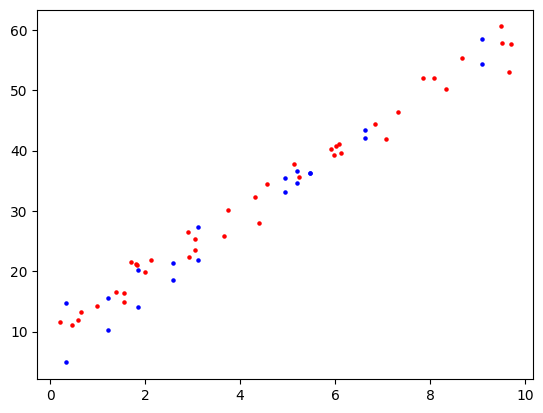

In [25]:
plt.scatter(X_train, y_train, s=5, c="r", label="Training Data")
plt.scatter(X_test, y_test, s=5, c="b", label="Test Data")
plt.scatter(X_test, y_preds, s=5, c="b", label="Predictions")

plt.show()